In [1]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax as dfrx
import equinox as eqx
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_nonessential_all_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
from scipy import stats
from cld4py import assign_letters, plot_letters

In [2]:
save_dir_base = '../../../results/predictions/exercise_long/'

resist_color = '#6b8ba4'
run_color = '#fc5a50'
plot_color = '#175449'

model = "MM_nonessential_all"
save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

width= 1.5
height= 1.25

Define and plot long-time exercise stimuli

Comes from Allen Leung Thesis Ch 4 and Blasev et al 2022 https://www.cell.com/cell-metabolism/fulltext/S1550-4131(22)00302-3#mmc2

In [3]:
Ca_baseline = 0.1
kHydro_baseline = 0.15 # 1/s

# Sprint
# 3 x 30s all out
Ca_stim_sprint = 10 # uM
kHydro_stim_sprint = 2.5 # 1/s
pulse_dir_sprint = 30 # sec
pulse_num_sprint = 3
stop_interval_sprint = 60 # sec
sets_sprint = 1
# total_time_sprint = 3*30 + 2*60 + 1800 # 3*30 sec + 2 min + 30 min

# Resistance
# 6 x 10 extensions
Ca_stim_resist = 4 # uM
kHydro_stim_resist = 1 # 1/s
pulse_dir_resist = 60 # sec
pulse_num_resist = 10
stop_interval_resist = 60 # sec
sets_resist = 6
total_time_resist = 3 * 10 + 60 * 5 + 1800 # 30 sec +/ 5 min + 30 min

# Endurance
# 1 x 90 min
Ca_stim_endurance = 0.5 # uM
kHydro_stim_endurance = 0.25 # 1/s
pulse_dir_endurance = 5400 # sec
pulse_num_endurance = 1
stop_interval_endurance = 60 # sec
sets_endurance = 1
# total_time_endurance = 5400 + 1800 # 90 min + 30 min

times = np.arange(0, 7200, 1) # seconds

def generate_square_pulse_signal(
    times, baseline, stim, pulse_duration, pulse_number, spacing, start_baseline=60
):
    """
    Generate a signal with prescribed number of instantaneous square pulses for a specified duration, spacing, and repetitions.
    Optionally, add additional off time after the pulses and an initial baseline period.
    If a times vector is provided, return the signal sampled at those times.

    Parameters
    ----------
    baseline : float
        Baseline value of the signal.
    stim : float
        Value during the pulse.
    pulse_duration : float
        Duration of each pulse (seconds).
    pulse_number : int
        Number of pulses per repetition.
    spacing : float
        Time between pulses (seconds).
    repetitions : int, optional
        Number of repetitions (default 1).
    off_time : float, optional
        Additional time at baseline after all pulses (default 0).
    start_baseline : float, optional
        Initial time at baseline before pulses start (default 60 seconds).
    times : array-like, optional
        If provided, return signal sampled at these time points.

    Returns
    -------
    times : jnp.ndarray
        Array of time points.
    signal : jnp.ndarray
        Array of signal values at each time point.
    """
    # Create a mask of the same shape as times, initialized to False
    # use this to set the signal to stim at the right times
    mask = jnp.zeros_like(times)

    # fill in mask accordingly
    stim_on_times = start_baseline + jnp.arange(pulse_number) * (pulse_duration + spacing)
    stim_off_times = stim_on_times + pulse_duration
    for i in range(pulse_number):
        mask = mask | ((times >= stim_on_times[i]) & (times < stim_off_times[i]))
    
    return mask*stim + (1 - mask) * baseline

Plots of the stimuli

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_34159/282195379.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_dir + 'Ca_signals.pdf', bbox_inches='tight' ,transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_34159/282195379.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_dir + 'kHydro_signals.pdf', bbox_inches='tight' ,transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


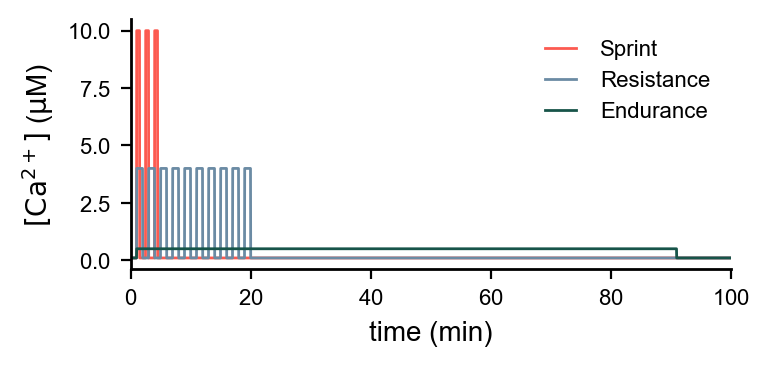

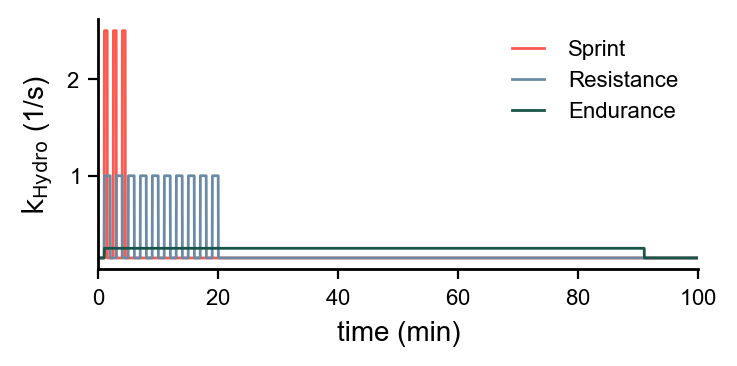

In [4]:
sprint_ca = generate_square_pulse_signal(times, Ca_baseline, Ca_stim_sprint, pulse_dir_sprint, pulse_num_sprint, stop_interval_sprint)
sprint_kHydro = generate_square_pulse_signal(times, kHydro_baseline, kHydro_stim_sprint, pulse_dir_sprint, pulse_num_sprint, stop_interval_sprint)
resist_ca = generate_square_pulse_signal(times, Ca_baseline, Ca_stim_resist, pulse_dir_resist, pulse_num_resist, stop_interval_resist)
resist_kHydro = generate_square_pulse_signal(times, kHydro_baseline, kHydro_stim_resist, pulse_dir_resist, pulse_num_resist, stop_interval_resist)
endurance_ca = generate_square_pulse_signal(times, Ca_baseline, Ca_stim_endurance, pulse_dir_endurance, pulse_num_endurance, stop_interval_endurance)
endurance_kHydro = generate_square_pulse_signal(times, kHydro_baseline, kHydro_stim_endurance, pulse_dir_endurance, pulse_num_endurance, stop_interval_endurance)

# calcium
fig, ax = get_sized_fig_ax(2*width, height)
ax.plot(times/60, sprint_ca, color=run_color, lw=1.0, label='Sprint')
ax.plot(times/60, resist_ca, color=resist_color, lw=1.0, label='Resistance')
ax.plot(times/60, endurance_ca, color=plot_color, lw=1.0, label='Endurance')
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel(r'$[Ca^{2+}]$ ($\mu$M)', fontsize=10)
ax.set_xlim(0, 100)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8, loc='upper right')
plt.savefig(save_dir + 'Ca_signals.pdf', bbox_inches='tight' ,transparent=True)

# kHydro
fig, ax = get_sized_fig_ax(2*width, height)
ax.plot(times/60, sprint_kHydro, color=run_color, lw=1.0, label='Sprint')
ax.plot(times/60, resist_kHydro, color=resist_color, lw=1.0, label='Resistance')
ax.plot(times/60, endurance_kHydro, color=plot_color, lw=1.0, label='Endurance')
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel(r'$k_{Hydro}$ (1/s)', fontsize=10)
ax.set_xlim(0, 100)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8, loc='upper right')
plt.savefig(save_dir + 'kHydro_signals.pdf', bbox_inches='tight' ,transparent=True)

In [5]:
# make interpolators and lambda functions
coeffs_ca_sprint = dfrx.backward_hermite_coefficients(times, sprint_ca)
interp_ca_sprint = dfrx.CubicInterpolation(times, coeffs_ca_sprint)
coeffs_kHydro_sprint = dfrx.backward_hermite_coefficients(times, sprint_kHydro)
interp_kHydro_sprint = dfrx.CubicInterpolation(times, coeffs_kHydro_sprint)

coeffs_ca_resist = dfrx.backward_hermite_coefficients(times, resist_ca)
interp_ca_resist = dfrx.CubicInterpolation(times, coeffs_ca_resist)
coeffs_kHydro_resist = dfrx.backward_hermite_coefficients(times, resist_kHydro)
interp_kHydro_resist = dfrx.CubicInterpolation(times, coeffs_kHydro_resist)


coeffs_ca_endurance = dfrx.backward_hermite_coefficients(times, endurance_ca)
interp_ca_endurance = dfrx.CubicInterpolation(times, coeffs_ca_endurance)
coeffs_kHydro_endurance = dfrx.backward_hermite_coefficients(times, endurance_kHydro)
interp_kHydro_endurance = dfrx.CubicInterpolation(times, coeffs_kHydro_endurance)

Set up: Model

In [6]:
sampler = "Pathfinder"

model = "MM_nonessential_all"
model_info_file = '../models/MM_nonessential_all.json'
data_dir = '../../../results/param_est/kinase_KO/std_dcr/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength
k_gly_idx = list(metab_params["metab_params_basal"].keys()).index("kGly")
k_hydro_idx = list(metab_params["metab_params_basal"].keys()).index("kHydro")

# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')


rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

ca_index = list(model_info["init_conds"].keys()).index("Ca")
total_AMPKAR = model_info["init_conds"]["AMPKAR"]

MM_non_all = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
rhs = dfrx.ODETerm(MM_non_all.time_dep_Ca_kHydro)

def dynamic_stim(params, rhs, y0, times, Ca_func, kHydro_func, Ca_basal, kHydro_basal,
        tmax_init=1e3, rtol=1e-6, atol=1e-6, pcoeff=0.3, 
        icoeff=0.4, dcoeff=0.0, dt0=1e-10, solver = dfrx.Kvaerno5()):
    """ Function to solve the ODE with dynamic stimuli. The time-dependent RHS func expercts functions for the Ca2+ concentration and kHydro rate as the final two params in the params list (calcium first, then kHydro)."""
    
    # solver details
    stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
    t0 = 0.0
    t1 = times[-1]
    saveat=dfrx.SaveAt(ts=times)
    # saveat=dfrx.SaveAt(t0=True, t1=True, steps=True)
    # max_steps=int(3)

    # first equilibrate the system with basal conditions
    ca_basal_func = lambda t: Ca_basal
    kHydro_basal_func = lambda t: kHydro_basal

    basal_params = list(params.copy())
    basal_params.append(ca_basal_func)
    basal_params.append(kHydro_basal_func)

    sol = dfrx.diffeqsolve(
        rhs, solver, 
        t0, tmax_init, dt0, 
        y0, 
        args=basal_params,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        throw=True)
    
    # now apply the dynamic stimuli
    stim_params = list(params.copy())
    stim_params.append(Ca_func)
    stim_params.append(kHydro_func)

    # run the simulation
    sol_stressed = dfrx.diffeqsolve(
        rhs, solver, 
        t0, t1, dt0, 
        sol.ys, # use basal SS at IC
        args=stim_params, 
        saveat=saveat,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        max_steps=1000000,
        throw=False)
    
    return sol_stressed

@jax.jit
def compute_pAMPK_act(param, interp_ca, interp_kHydro, times):

    ca_t = lambda t: interp_ca.evaluate(t)
    kHydro_t = lambda t: interp_kHydro.evaluate(t)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, times, ca_t, kHydro_t, 0.1, 0.15,
                   atol=1e-6, rtol=1e-6)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(jnp.squeeze(jnp.array(sol.ys)), param)

    # compute the AUC
    return pAMPK_activity, sol.ys


def compute_pAMPK_activity(sol, param, pampk_idxs=np.array([10, 15, 16]), amp_pampk_idx=14):
    return sol[pampk_idxs, :].sum(axis=0)*param[12] + sol[amp_pampk_idx, :]*param[12]*param[24]

Run simulations

In [ ]:
# random sample from the posterior
nsamples=50
params = get_param_subsample(param_names, idata_cyto, nsamples) # one param for now, then draw a random subset

# sprint
sprint_sims = []
for i in range(nsamples):
    sprint_sim = compute_pAMPK_act(params[i], interp_ca_sprint, interp_kHydro_sprint, times)
    sprint_sims.append(sprint_sim)

# resistance
resist_sims = []
for i in range(nsamples):
    resist_sim = compute_pAMPK_act(params[i], interp_ca_resist, interp_kHydro_resist, times)
    resist_sims.append(resist_sim)

# endurance
endurance_sims = []
for i in range(nsamples):
    endurance_sim = compute_pAMPK_act(params[i], interp_ca_endurance, interp_kHydro_endurance, times)
    endurance_sims.append(endurance_sim)

/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/ampk_models/prediction/../plotting_helper_funcs.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/ampk_models/prediction/../plotting_helper_funcs.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(filename, dpi="figure", bbox_inches=bbox, transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/1089223693.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'sprint_pAMPK_act.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/1089223693.py:59: UserWarning: This figure include

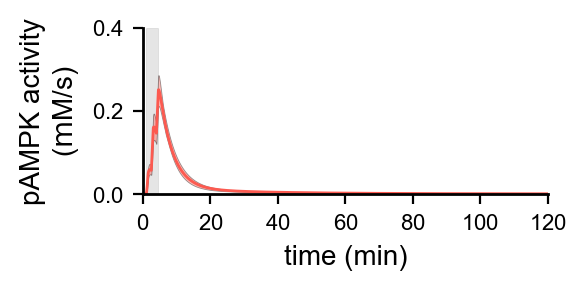

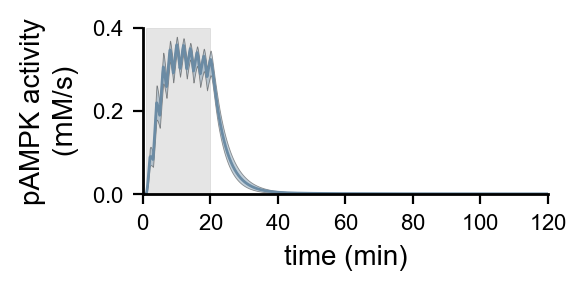

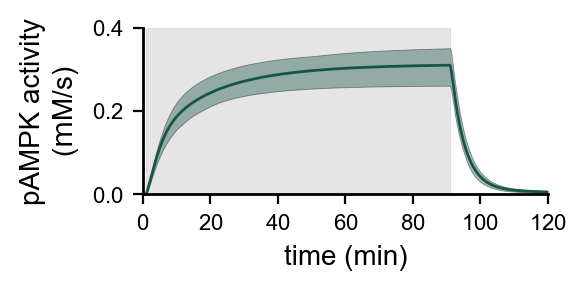

In [ ]:
# sprint
ylim = (0, 0.4)
fig, ax = get_sized_fig_ax(1.35*width, height/1.5)

# shading during stimulus
ax.axvspan(1, 4.5, color='gray', alpha=0.2, label='stimulus')

# plot sims
sims = []
for i in range(nsamples):
    sim = sprint_sims[i][0]
    sims.append(sim)

    # plot the calcium flux
    # ax.plot(times/60, sim, linewidth=1.0, color=run_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.0, color=run_color, label='mean')
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=run_color, alpha=0.4, edgecolor='k', label='95% credible interval')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)

leg = ax.legend(fontsize=8, loc='upper right', handletextpad=0.5, borderpad=0.2, labelspacing=0.2)
export_legend(leg, save_dir + 'legend_sprint.pdf')
leg.remove()

fig.savefig(save_dir + 'sprint_pAMPK_act.pdf', bbox_inches='tight', 
            transparent=True)

# resistance
fig, ax = get_sized_fig_ax(1.35*width, height/1.5)

# shading during stimulus
ax.axvspan(1, 20, color='gray', alpha=0.2)

sims = []
for i in range(nsamples):
    sim = resist_sims[i][0]
    sims.append(sim)

    # plot the calcium flux
    # ax.plot(times/60, sim, linewidth=1.0, color=resist_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.0, color=resist_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=resist_color, alpha=0.4, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_pAMPK_act.pdf', bbox_inches='tight', 
            transparent=True)

# endurance
fig, ax = get_sized_fig_ax(1.35*width, height/1.5)

# shading during stimulus
ax.axvspan(1, 91, color='gray', alpha=0.2)

sims = []
for i in range(nsamples):
    sim = endurance_sims[i][0]
    sims.append(sim)

    # plot the calcium flux
    # ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.0, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.4, edgecolor='k')

# ax.set_xlim(0, 10)
ylim = ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'endurance_pAMPK_act.pdf', bbox_inches='tight', 
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2612869528.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'sprint_AMP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2612869528.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_AMP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2612869528.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'endurance_AMP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2612869528.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(sav

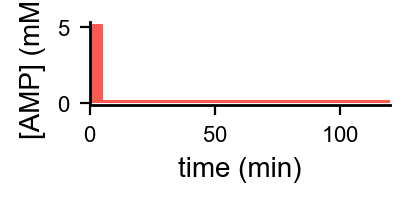

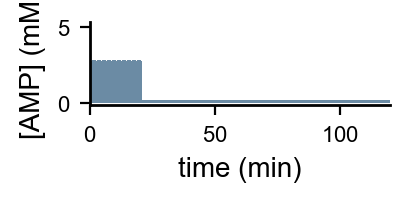

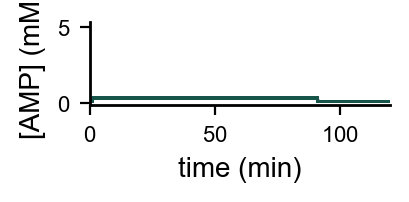

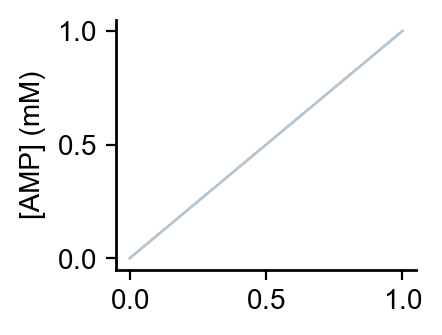

In [ ]:
fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = sprint_sims[i][1][0]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=run_color, alpha=0.5)

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
ax.set_xlim(0, 120)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'sprint_AMP.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = resist_sims[i][1][0]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=resist_color, alpha=0.5)

# ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylim(ylim)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'resistance_AMP.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = endurance_sims[i][1][0]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.5)

# ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylim(ylim)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'endurance_AMP.pdf', bbox_inches='tight', 
            transparent=True)

# dummy plot with ylabel
fig, ax = get_sized_fig_ax(width, height)
ax.plot([0, 1], [0, 1], linewidth=1.0, color=resist_color, alpha=0.5)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
fig.savefig(save_dir + 'AMP_ylab.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2932980786.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'sprint_ATP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2932980786.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_ATP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2932980786.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'endurance_ATP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2932980786.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(sav

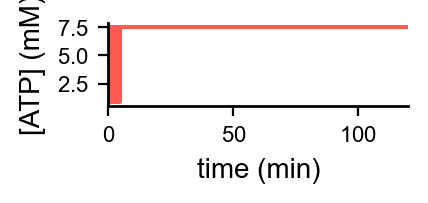

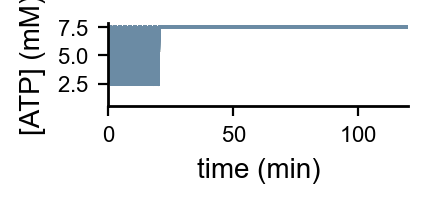

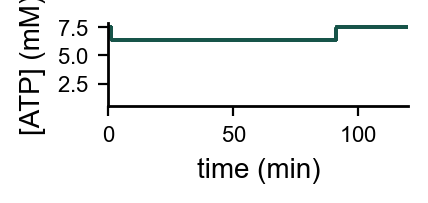

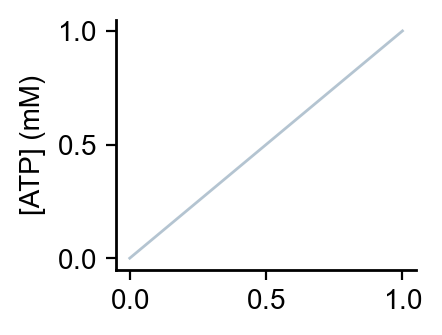

In [ ]:
fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = sprint_sims[i][1][2]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=run_color, alpha=0.5)

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
ax.set_xlim(0, 120)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'sprint_ATP.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = resist_sims[i][1][2]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=resist_color, alpha=0.5)

# ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylim(ylim)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'resistance_ATP.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = endurance_sims[i][1][2]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.5)

# ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylim(ylim)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'endurance_ATP.pdf', bbox_inches='tight', 
            transparent=True)

# dummy plot with ylabel
fig, ax = get_sized_fig_ax(width, height)
ax.plot([0, 1], [0, 1], linewidth=1.0, color=resist_color, alpha=0.5)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
fig.savefig(save_dir + 'ATP_ylab.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3447339172.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'sprint_CaMKK2.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3447339172.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_CaMKK2.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3447339172.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'endurance_CaMKK2.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3447339172.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.sa

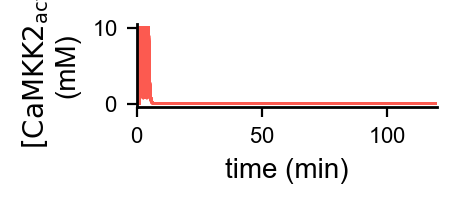

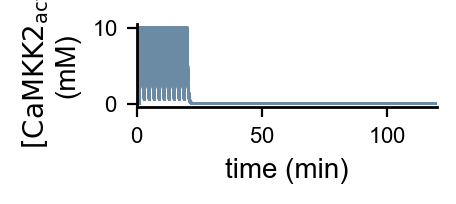

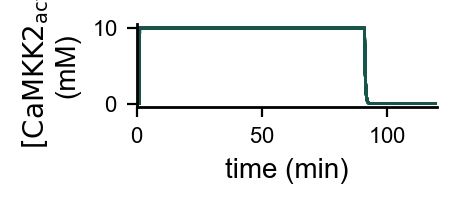

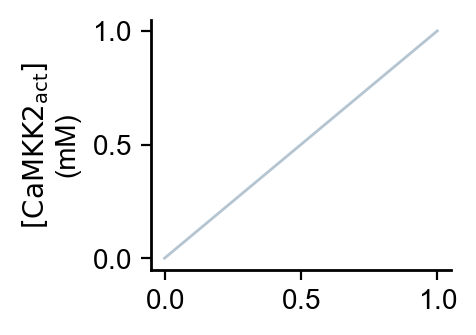

In [ ]:
fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = sprint_sims[i][1][8]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=run_color, alpha=0.5)

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
ax.set_xlim(0, 120)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'sprint_CaMKK2.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = resist_sims[i][1][8]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=resist_color, alpha=0.5)

# ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylim(ylim)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'resistance_CaMKK2.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = endurance_sims[i][1][8]
    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.5)

# ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylim(ylim)
# ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'endurance_CaMKK2.pdf', bbox_inches='tight', 
            transparent=True)

# dummy plot with ylabel
fig, ax = get_sized_fig_ax(width, height)
ax.plot([0, 1], [0, 1], linewidth=1.0, color=resist_color, alpha=0.5)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
fig.savefig(save_dir + 'CaMKK2_ylab.pdf', bbox_inches='tight',
            transparent=True)

### Upstream kinase knockouts

In [ ]:
@jax.jit
def compute_pAMPK_act_LKB1_KO(param, interp_ca, interp_kHydro, times):

    
    ca_t = lambda t: interp_ca.evaluate(t)
    kHydro_t = lambda t: interp_kHydro.evaluate(t)

    lkb1_tot_idx = 16
    lkb1_phos_idx = 8
    # print(param)
    # set the LKB1 total concentration to 0
    param = param.at[lkb1_tot_idx].set(0.0)
    param = param.at[lkb1_phos_idx].set(0.0)
    # param[lkb1_tot_idx] = 0.0
    # print(param)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, times, ca_t, kHydro_t, 0.1, 0.15,
                   atol=1e-6, rtol=1e-6)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(jnp.squeeze(jnp.array(sol.ys)), param)

    return pAMPK_activity, sol.ys

@jax.jit
def compute_pAMPK_act_CaMKK2_KO(param,  interp_ca, interp_kHydro, times):

    ca_t = lambda t: interp_ca.evaluate(t)
    kHydro_t = lambda t: interp_kHydro.evaluate(t)

    CaMKK2_idx = 7
    # set the LKB1 total concentration to 0
    y0_local = y0.copy()
    y0_local[CaMKK2_idx] = 0.0
    # y0 = y0.at[CaMKK2_idx].set(0.0)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0_local, times, ca_t, kHydro_t, 0.1, 0.15,
                   atol=1e-6, rtol=1e-6)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(jnp.squeeze(jnp.array(sol.ys)), param)

    return pAMPK_activity, sol.ys

In [ ]:
# sprint
sprint_sims_LKB1_KO = []
sprint_sims_CaMKK2_KO = []
for i in range(nsamples):
    sprint_sim_LKB1_KO = compute_pAMPK_act_LKB1_KO(params[i], interp_ca_sprint, interp_kHydro_sprint, times)
    sprint_sims_LKB1_KO.append(sprint_sim_LKB1_KO)

    sprint_sim_CaMKK2_KO = compute_pAMPK_act_CaMKK2_KO(params[i], interp_ca_sprint, interp_kHydro_sprint, times)
    sprint_sims_CaMKK2_KO.append(sprint_sim_CaMKK2_KO)

# resistance
resist_sims_LKB1_KO = []
resist_sims_CaMKK2_KO = []
for i in range(nsamples):
    resist_sim_LKB1_KO = compute_pAMPK_act_LKB1_KO(params[i], interp_ca_resist, interp_kHydro_resist, times)
    resist_sims_LKB1_KO.append(resist_sim_LKB1_KO)

    resist_sim_CaMKK2_KO = compute_pAMPK_act_CaMKK2_KO(params[i], interp_ca_resist, interp_kHydro_resist, times)
    resist_sims_CaMKK2_KO.append(resist_sim_CaMKK2_KO)

# endurance
endurance_sims_LKB1_KO = []
endurance_sims_CaMKK2_KO = []
for i in range(nsamples):
    endurance_sim_LKB1_KO = compute_pAMPK_act_LKB1_KO(params[i], interp_ca_endurance, interp_kHydro_endurance, times)
    endurance_sims_LKB1_KO.append(endurance_sim_LKB1_KO)

    endurance_sim_CaMKK2_KO = compute_pAMPK_act_CaMKK2_KO(params[i], interp_ca_endurance, interp_kHydro_endurance, times)
    endurance_sims_CaMKK2_KO.append(endurance_sim_CaMKK2_KO)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3679683044.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'sprint_pAMPK_act_LKB1_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3679683044.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_pAMPK_act_LKB1_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/3679683044.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'endurance_pAMPK_act_LKB1_KO.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layo

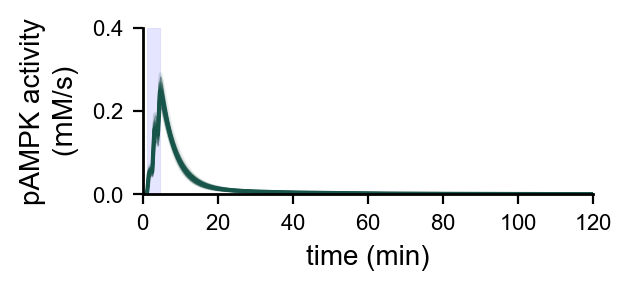

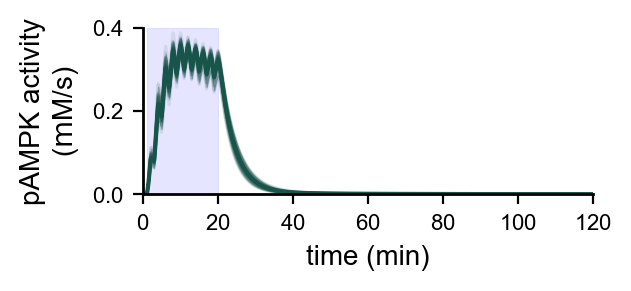

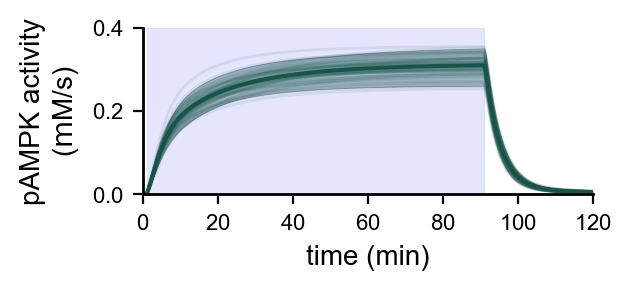

In [ ]:
# sprint
ylim = (0, 0.4)
fig, ax = get_sized_fig_ax(1.5*width, height/1.5)

# shading during stimulus
ax.axvspan(1, 4.5, color='blue', alpha=0.1)

# plot sims
sims = []
for i in range(nsamples):
    sim = sprint_sims_LKB1_KO[i][0]
    sims.append(sim)

    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.3, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'sprint_pAMPK_act_LKB1_KO.pdf', bbox_inches='tight', 
            transparent=True)

# resistance
fig, ax = get_sized_fig_ax(1.5*width, height/1.5)

# shading during stimulus
ax.axvspan(1, 20, color='blue', alpha=0.1)

sims = []
for i in range(nsamples):
    sim = resist_sims_LKB1_KO[i][0]
    sims.append(sim)

    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.2, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_pAMPK_act_LKB1_KO.pdf', bbox_inches='tight', 
            transparent=True)

# endurance
fig, ax = get_sized_fig_ax(1.5*width, height/1.5)

# shading during stimulus
ax.axvspan(1, 91, color='blue', alpha=0.1)

sims = []
for i in range(nsamples):
    sim = endurance_sims_LKB1_KO[i][0]
    sims.append(sim)

    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.3, edgecolor='k')

# ax.set_xlim(0, 10)
ylim = ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'endurance_pAMPK_act_LKB1_KO.pdf', bbox_inches='tight', 
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/914241036.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'sprint_pAMPK_act_CaMKK2_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/914241036.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_pAMPK_act_CaMKK2_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/914241036.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'endurance_pAMPK_act_CaMKK2_KO.pdf', bbox_inches='tight',


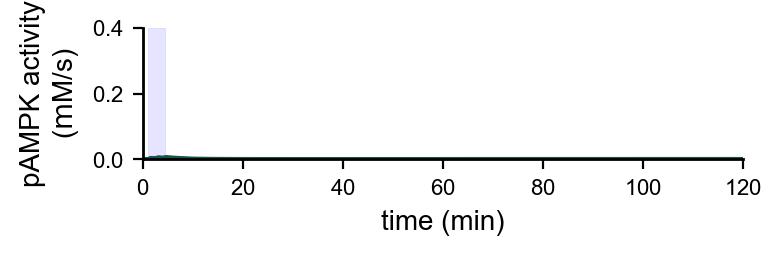

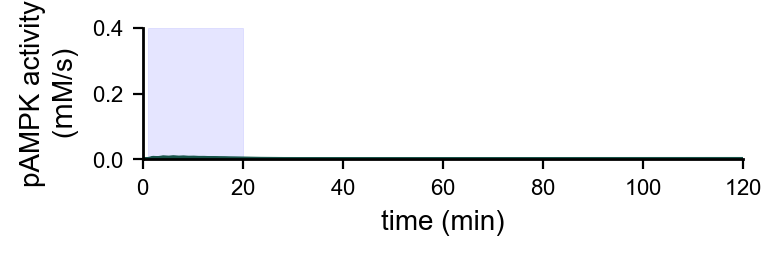

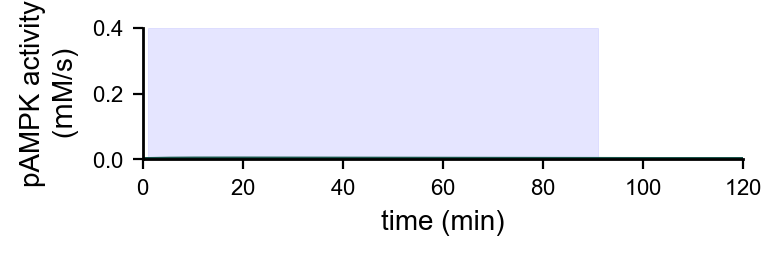

In [ ]:
# sprint
ylim = (0, 0.4)
fig, ax = get_sized_fig_ax(2*width, height/1.9)

# shading during stimulus
ax.axvspan(1, 4.5, color='blue', alpha=0.1)

# plot sims
sims = []
for i in range(nsamples):
    sim = sprint_sims_CaMKK2_KO[i][0]
    sims.append(sim)

    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.3, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'sprint_pAMPK_act_CaMKK2_KO.pdf', bbox_inches='tight', 
            transparent=True)

# resistance
fig, ax = get_sized_fig_ax(2*width, height/1.9)

# shading during stimulus
ax.axvspan(1, 20, color='blue', alpha=0.1)

sims = []
for i in range(nsamples):
    sim = resist_sims_CaMKK2_KO[i][0]
    sims.append(sim)

    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.2, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_pAMPK_act_CaMKK2_KO.pdf', bbox_inches='tight', 
            transparent=True)

# endurance
fig, ax = get_sized_fig_ax(2*width, height/1.9)

# shading during stimulus
ax.axvspan(1, 91, color='blue', alpha=0.1)

sims = []
for i in range(nsamples):
    sim = endurance_sims_CaMKK2_KO[i][0]
    sims.append(sim)

    # plot the calcium flux
    ax.plot(times/60, sim, linewidth=1.0, color=plot_color, alpha=0.1)
ax.plot(times/60, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(times/60, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.3, edgecolor='k')

# ax.set_xlim(0, 10)
ylim = ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (min)', fontsize=10)
ax.set_xlim(0, 120)
ax.set_ylabel('pAMPK activity\n'+r'($m$M/s)', fontsize=10)
fig.savefig(save_dir + 'endurance_pAMPK_act_CaMKK2_KO.pdf', bbox_inches='tight', 
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2878142377.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dat_long, ax=ax, x='condition', y='AMPK activity',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2878142377.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'exercise_AMPK_activity_barplot.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not comp

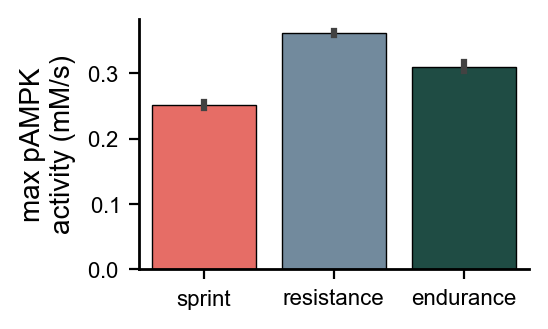

In [ ]:
# barplot of WT 
sprint_final_act = [float(np.max(sprint_sims[i][0])) for i in range(nsamples)]
resist_final_act = [float(np.max(resist_sims[i][0])) for i in range(nsamples)]
endurance_final_act = [float(np.max(endurance_sims[i][0])) for i in range(nsamples)]


dat_df = pd.DataFrame({'sprint': sprint_final_act, 'resistance': resist_final_act, 'endurance': endurance_final_act})

dat_long = dat_df.reset_index().melt(id_vars='index', var_name='condition', 
                    value_name='AMPK activity').drop('index', axis=1)

fig, ax = get_sized_fig_ax(1.3*width, height)
sns.barplot(data=dat_long, ax=ax, x='condition', y='AMPK activity',
            palette={'sprint': run_color, 'resistance': resist_color, 'endurance': plot_color},
            linewidth=0.5, edgecolor='black')
ax.set_ylabel('max pAMPK\nactivity ' + r'(mM/s)', fontsize=10)
ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=8)
fig.savefig(save_dir + 'exercise_AMPK_activity_barplot.pdf', bbox_inches='tight',
            transparent=True)

Plot a barplot with all conditions and add statistical significance

In [ ]:
sprint_final_act = [float(np.max(sprint_sims[i][0])) for i in range(nsamples)]
resist_final_act = [float(np.max(resist_sims[i][0])) for i in range(nsamples)]
endurance_final_act = [float(np.max(endurance_sims[i][0])) for i in range(nsamples)]

sprint_final_act_LKB1_KO = [float(np.max(sprint_sims_LKB1_KO[i][0])) for i in range(nsamples)]
resist_final_act_LKB1_KO = [float(np.max(resist_sims_LKB1_KO[i][0])) for i in range(nsamples)]
endurance_final_act_LKB1_KO = [float(np.max(endurance_sims_LKB1_KO[i][0])) for i in range(nsamples)]

sprint_final_act_CaMKK2_KO = [float(np.max(sprint_sims_CaMKK2_KO[i][0])) for i in range(nsamples)]
resist_final_act_CaMKK2_KO = [float(np.max(resist_sims_CaMKK2_KO[i][0])) for i in range(nsamples)]
endurance_final_act_CaMKK2_KO = [float(np.max(endurance_sims_CaMKK2_KO[i][0])) for i in range(nsamples)]

sprint_df = pd.DataFrame({'WT':sprint_final_act, 'LKB1 KO': sprint_final_act_LKB1_KO, 'CaMKK2 KO': sprint_final_act_CaMKK2_KO})
resist_df = pd.DataFrame({'WT':resist_final_act, 'LKB1 KO': resist_final_act_LKB1_KO, 'CaMKK2 KO': resist_final_act_CaMKK2_KO})
endurance_df = pd.DataFrame({'WT':endurance_final_act, 'LKB1 KO': endurance_final_act_LKB1_KO, 'CaMKK2 KO': endurance_final_act_CaMKK2_KO})

sprint_df_long = sprint_df.reset_index().melt(id_vars='index',
                var_name='condition', value_name='AMPK activity').drop('index', axis=1)
sprint_df_long['exercise'] = 'sprint'
resist_df_long = resist_df.reset_index().melt(id_vars='index',
                var_name='condition', value_name='AMPK activity').drop('index', axis=1)
resist_df_long['exercise'] = 'resistance'
endurance_df_long = endurance_df.reset_index().melt(id_vars='index',
                var_name='condition', value_name='AMPK activity').drop('index', axis=1)
endurance_df_long['exercise'] = 'endurance'

sprint_df_long['exercise'] = sprint_df_long['exercise'].astype('category')
resist_df_long['exercise'] = resist_df_long['exercise'].astype('category')
endurance_df_long['exercise'] = endurance_df_long['exercise'].astype('category')

df_long = pd.concat([sprint_df_long, resist_df_long, endurance_df_long], axis=0)

Perform an ANOVA test and post-hoc test


In [ ]:
# Get all unique groups
groups = df_long.groupby(['condition', 'exercise'])['AMPK activity'].apply(list)

# Perform one-way ANOVA across all groups
anova_result = stats.f_oneway(*groups)
anova_result

# compute n_comparison pairs to apply Bonferroni correction
n_comparisons = len(groups) * (len(groups) - 1) / 2
alpha_corrected = 0.05 / n_comparisons

comparisons_df = pd.DataFrame()

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1, group2 = groups.keys()[i], groups.keys()[j]
      
        t_stat, p_value = stats.ttest_ind(groups[group1], groups[group2])
        comparisons_df = pd.concat([comparisons_df, 
                                    pd.DataFrame({'group1':group1[1] + '-' + group1[0],
                                                  'group2':group2[1] + '-' + group2[0],
                                                  'pvalue':p_value},index=[0])])
    

order = ['sprint-WT', 'resistance-WT', 'endurance-WT', 'sprint-LKB1 KO', 'resistance-LKB1 KO', 'endurance-LKB1 KO', 'sprint-CaMKK2 KO', 'resistance-CaMKK2 KO', 'endurance-CaMKK2 KO',]


# assign cld letters
cld_results = assign_letters(comparisons_df, G1='group1', G2='group2', P='pvalue',
                             order=order, alpha=alpha_corrected)

# now process the cld_results so that it is suitable for plotting in the hue grouped barplot
cld_df = cld_results['Letters'].reset_index()
cld_df.columns = ['Group', 'Letters']
cld_df['exercise'] = cld_df['Group'].apply(lambda x: x.split('-')[0])
cld_df['condition'] = cld_df['Group'].apply(lambda x: x.split('-')[1])
cld_df = cld_df.drop(columns=['Group'])
cld_df['Letters'] = cld_df['Letters'].str.upper()


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_43765/2294538140.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'exercise_AMPK_activity_barplot_kinase_KO.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


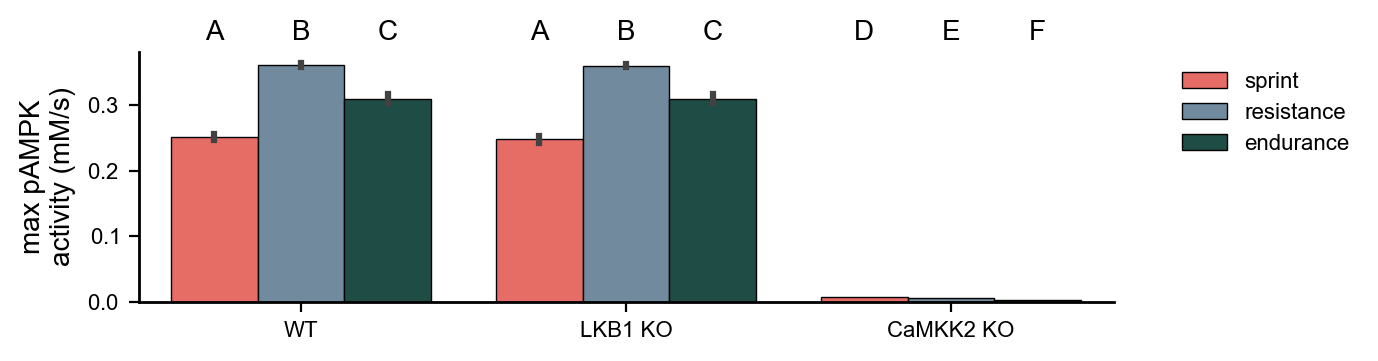

In [ ]:
fig, ax = get_sized_fig_ax(3.25*width, height)
sns.barplot(data=df_long, ax=ax, x='condition', y='AMPK activity', hue='exercise',
            palette={'sprint':run_color,'resistance': resist_color, 'endurance': plot_color},
            linewidth=0.5, edgecolor='black')
ax.set_ylabel('max pAMPK\nactivity ' + r'(mM/s)', fontsize=10)
ax.legend(title='', fontsize=8, title_fontsize=8,
            loc='upper left', bbox_to_anchor=(1.05, 1), )
ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=8)

ylim = ax.get_ylim()
# Add CLD letters above each bar
for i, bar in enumerate(ax.patches):
    # Get the corresponding exercise and condition for each bar
    if i < 9:
        exercise = ax.get_legend_handles_labels()[1][i // 3]
        condition = ax.get_xticklabels()[i % 3].get_text()
        # Find the letter for this group
        letter_row = cld_df[(cld_df['exercise'] == exercise) & (cld_df['condition'] == condition)]
        if not letter_row.empty:
            letter = letter_row['Letters'].values[0]
            height_local = ylim[1] #bar.get_height()
            ax.annotate(letter, 
                        (bar.get_x() + bar.get_width() / 2, height_local), 
                        ha='center', va='bottom', fontsize=10, #fontweight='bold', 
                        xytext=(0, 2), textcoords='offset points')
            
fig.savefig(save_dir + 'exercise_AMPK_activity_barplot_kinase_KO.pdf', bbox_inches='tight',
            transparent=True)
